In [25]:
from erddapy import ERDDAP
import matplotlib.pyplot as plt

e = ERDDAP(
    server="https://gliders.ioos.us/erddap",
    protocol="tabledap",
    response="csv",
)
e.dataset_id = "sg686-20250109T1810"

e.variables = [
    "depth",
    "latitude",
    "longitude",
    "salinity",
    "temperature",
    "dissolved_oxygen",
    "density",
    "profile_id",
    "time",
]

df = e.to_pandas(
    index_col="time (UTC)",
    parse_dates=True,
)
df.head()

,depth (m),latitude (degrees_north),longitude (degrees_east),salinity (1),temperature (Celsius),dissolved_oxygen (micromoles/kg),density (kg m-3),profile_id
time (UTC),,,,,,,,
2025-03-13 23:31:41+00:00,42.68,44.5576,-123.2841,30.25,20.086,207.2867,1021.13,26
2025-03-13 23:31:41+00:00,42.18,44.5576,-123.2841,30.25,20.093,207.1955,1021.13,26
2025-03-13 23:31:41+00:00,41.68,44.5576,-123.2841,30.25,20.094,207.2765,1021.13,26
2025-03-13 23:31:41+00:00,41.16,44.5576,-123.2841,30.25,20.095,207.2483,1021.13,26
2025-03-13 23:31:41+00:00,40.62,44.5576,-123.2841,30.25,20.100,207.2035,1021.12,26


Text(0, 0.5, 'Salinity (PSU)')

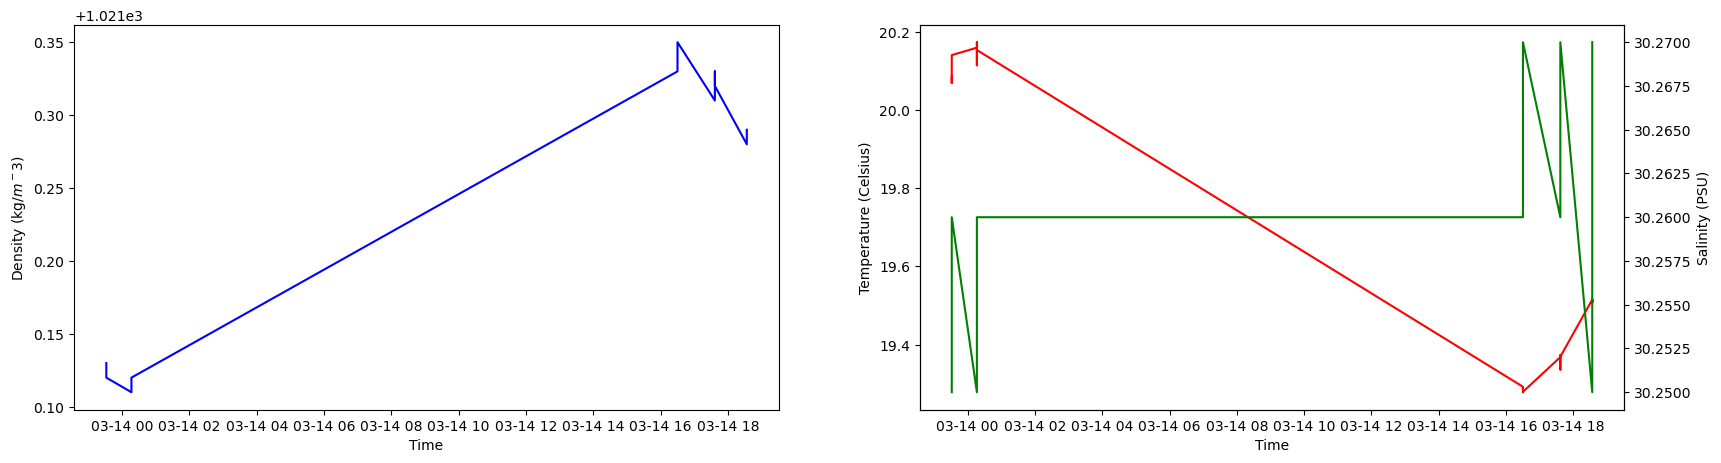

In [31]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20, 5))

ax1.plot(df.index, df["density (kg m-3)"], label="Density", color="blue")
ax1.set_xlabel("Time")
ax1.set_ylabel(f"Density (kg/$m^-3$)")

ax2.plot(df.index, df["temperature (Celsius)"], label="Temperature", color="red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (Celsius)")
ax3 = ax2.twinx()
ax3.plot(df.index, df["salinity (1)"], label="Salinity", color="green")
ax3.set_ylabel("Salinity (PSU)")